In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,precision_score, recall_score,f1_score,roc_auc_score,roc_curve,confusion_matrix,classification_report

### 1. Data Exploration

In [2]:
df = pd.read_csv("diabetes.csv")

In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
### Checking Missing Values
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [6]:
### Checking Duplicates
df.duplicated().sum()

0

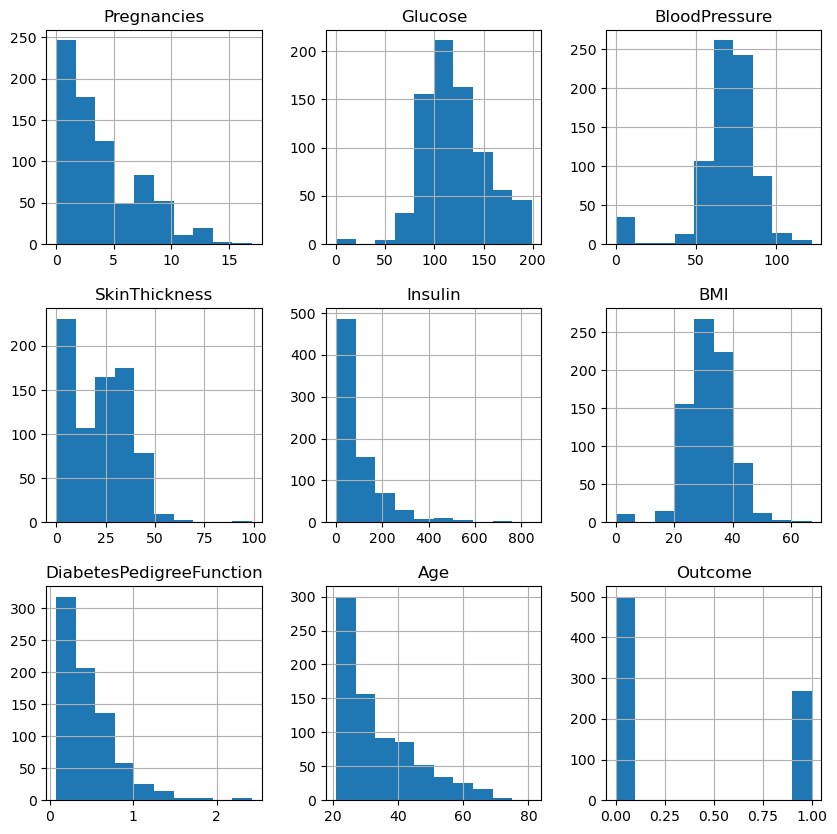

In [7]:
### Histogram
df.hist(figsize=(10,10))
plt.show()

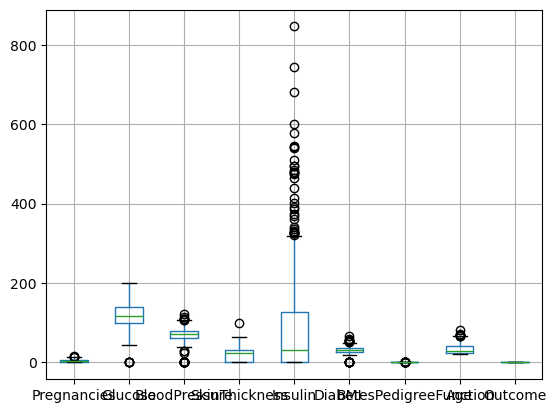

In [8]:
### BoxPlot
df.boxplot()
plt.show()

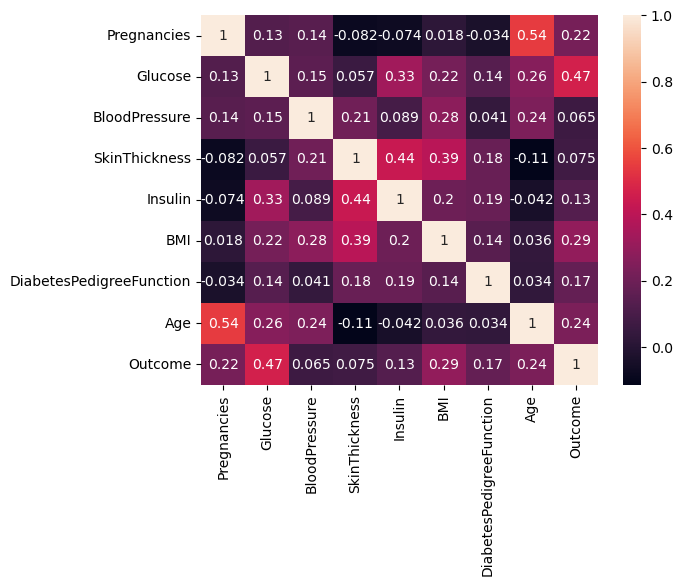

In [9]:
### HeatMap
plt.figure()
sns.heatmap(df.corr(),annot=True)
plt.show()

### 2. Data Preprocessing:

In [10]:
### Features and Target
target=df[['Outcome']]
features= df.drop(columns=['Outcome'])

In [11]:
### Train-Test Split
x_train,x_test,y_train,y_test = train_test_split(features,target,train_size = 0.8,random_state = 42)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(614, 8)
(154, 8)
(614, 1)
(154, 1)


### 3. Model Building

In [12]:
### Scaling
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [13]:
### Logistic Regression
model = LogisticRegression()
model.fit(x_train,y_train)

LogisticRegression()

### 4. Model Evaluation

In [14]:
y_pred= model.predict(x_test)
y_pred

array([0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1,
       0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
      dtype=int64)

In [15]:
y_prob = model.predict_proba(x_test)[:,1]

In [16]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.7532467532467533
Precision: 0.6491228070175439
Recall: 0.6727272727272727
F1-score: 0.6607142857142857
ROC-AUC: 0.8146923783287419


In [17]:
### Classification Report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.81      0.80      0.81        99
           1       0.65      0.67      0.66        55

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.75      0.75       154



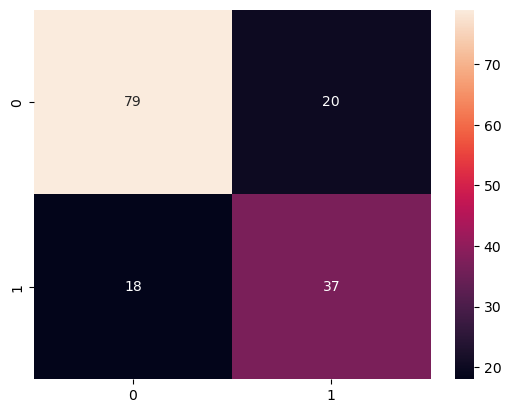

In [18]:
### Confusion Matrix
conf = confusion_matrix(y_test,y_pred)
sns.heatmap(conf,annot=True)
plt.show()

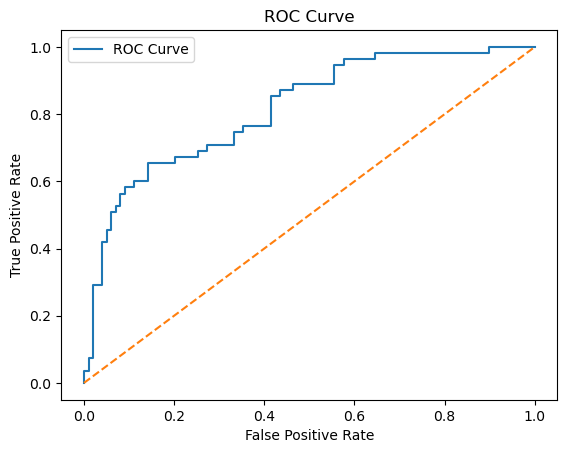

In [19]:
fpr, tpr, thr = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label="ROC Curve")
plt.plot([0,1], [0,1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


### 5. Interpretation

In [ ]:
coef_df = pd.DataFrame({
    "Feature": df.drop("Outcome", axis=1).columns,
    "Coefficient": model.coef_[0]
}).sort_values(by="Coefficient")

coef_df

### 6. Deployement with Streamlit

In [21]:
%%writefile app.py
import streamlit as st
import pickle
import numpy as np

model = pickle.load(open("model.pkl", "rb"))
scaler = pickle.load(open("scaler.pkl", "rb"))

st.title("Diabetes Prediction App")

preg = st.number_input("Pregnancies", 0)
glucose = st.number_input("Glucose", 0)
bp = st.number_input("Blood Pressure", 0)
skin = st.number_input("Skin Thickness", 0)
insulin = st.number_input("Insulin", 0)
bmi = st.number_input("BMI", 0.0)
dpf = st.number_input("Diabetes Pedigree Function", 0.0)
age = st.number_input("Age", 0)

data = scaler.transform([[preg, glucose, bp, skin, insulin, bmi, dpf, age]])

if st.button("Predict"):
    prediction = model.predict(data)[0]
    st.write("Result:", "Diabetic" if prediction == 1 else "Not Diabetic")


Overwriting app.py


In [ ]:
!streamlit run app.py

In [ ]:
2. What is cross-validation and why is it important?

Cross-validation splits data into multiple train/test sets to make sure the model is stable and not overfitting.